### Goal of this notebook is to analyze mouse bulk RNA-seq data from heart at different time points 
### compare this to the important TFs obtained from CM perturb-seq
### genes from TF perturb seq data (low usage vs high usage) to public dataset with mouse expression levels.

### downloaded the mouse expression data (poly A RNA seq) for heart from encode. - tsv files
#### https://www.encodeproject.org/search/?type=Experiment&status=released&perturbed=false&replicates.library.biosample.donor.organism.scientific_name=Mus+musculus&assay_title=polyA+plus+RNA-seq&biosample_ontology.term_name=heart&files.file_type=tsv&lab.title=Barbara+Wold%2C+Caltech
### lab - Baraba wold - caltech - (chose this because they had the maximum time points
#### quantify the expression level of some genes comparing across time course 


In [83]:
## #import scrublet as scr
import numpy as np
import pandas as pd
import statistics as st
import re
import csv
import scanpy as sc 
#i#mport scanpy.external as sce

import matplotlib
from matplotlib import pyplot as plt
import warnings
from scipy.stats import binom
from scipy.stats import multinomial
import seaborn
from scipy.stats import hypergeom
import warnings
warnings.filterwarnings('ignore')
import requests
import seaborn as sns

In [5]:
import os
os.getcwd()

'/home2/s438217/jupyter_notebooks/jupyter_notebooks_backup/IGVF_analysis/TF_perturb_seq_full/figures_for_paper/public_dataset'

In [6]:
#### read the tsv files
metadata =  pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/metadata.tsv', sep='\t')

In [7]:
E_10_5 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF770SOB.tsv', sep='\t')
E_11_5 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF159DWP.tsv', 
                     sep='\t')
E_12_5 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF484QWQ.tsv', sep='\t')
E_13_5 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF148BEQ.tsv', sep='\t')
E_14_5 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF554PCI.tsv', sep='\t')
E_15_5 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF868TGE.tsv', sep='\t')
E_16_5 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF110ZFH.tsv', sep='\t')
P_0 = pd.read_csv('/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/ENCFF611VKF.tsv', sep='\t')


In [8]:
P_0['gene_id_split'] = P_0['gene_id'].str.split('.').str[0]

In [9]:
filtered_P_0 = P_0[P_0['gene_id_split'].str.startswith('ENSMUSG')]


### converting gene ID to gene symbol

In [17]:
def fetch_gene_symbol(ensembl_gene_id):
    api_url = f'https://rest.ensembl.org/lookup/id/{ensembl_gene_id}?expand=1'
    response = requests.get(api_url, headers={"Content-Type": "application/json"})
    
    if response.status_code == 200:
        data = response.json()
        gene_symbol = data.get('display_name', 'N/A')
        return gene_symbol
    else:
        print(f"Error fetching gene ID {ensembl_gene_id}: {response.text}")
        return None


In [3]:
filtered_P_0['external_gene_name'] = filtered_P_0['gene_id_split'].apply(fetch_gene_symbol)


In [ ]:
filtered_P_0.to_csv("/home2/s438217/jupyter_notebooks/jupyter_notebooks_backup/IGVF_analysis/TF_perturb_seq_full/figures_for_paper/public_dataset_analysis/P0_with_gene_symbol.csv")

## loading the P0 file with gene symbol

In [10]:
filtered_P_0 = pd.read_csv("/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/P0_with_gene_symbol.csv")

In [11]:
gene_id = filtered_P_0["gene_id_split"]

In [12]:
gene_symbol = filtered_P_0["external_gene_name"]

In [13]:
id_to_symbol = dict(zip(gene_id,gene_symbol))

### map the gene IDs  and gene symbols for other dataframes

#### function to map the gene ID to symbol

In [14]:
def id_to_symbol_fn(df,gene_id_column,dict_id_to_symbol):
    df['gene_id_split'] = df[gene_id_column].str.split('.').str[0]
    filtered_df = df[df['gene_id_split'].str.startswith('ENSMUSG')]
    filtered_df['external_gene_name'] = filtered_df['gene_id_split'].map(dict_id_to_symbol)
    
    return(filtered_df)

    

    
    

In [15]:
filtered_E_10_5 = id_to_symbol_fn(E_10_5,'gene_id',id_to_symbol)
filtered_E_11_5 = id_to_symbol_fn(E_11_5,'gene_id',id_to_symbol)
filtered_E_12_5 = id_to_symbol_fn(E_12_5,'gene_id',id_to_symbol)
filtered_E_13_5 = id_to_symbol_fn(E_13_5,'gene_id',id_to_symbol)
filtered_E_14_5 = id_to_symbol_fn(E_14_5,'gene_id',id_to_symbol)
filtered_E_15_5 = id_to_symbol_fn(E_15_5,'gene_id',id_to_symbol)
filtered_E_16_5 = id_to_symbol_fn(E_16_5,'gene_id',id_to_symbol)
filtered_P_0 = id_to_symbol_fn(P_0,'gene_id',id_to_symbol)

#### change the column name of TPM to include the time point

In [16]:
def column_name_change(df,old_column,new_column):
    df = df.rename(columns={old_column:new_column})
    return(df)
    
    

In [17]:
filtered_E_10_5 = column_name_change(filtered_E_10_5,"TPM","E_10_5_TPM")
filtered_E_11_5 = column_name_change(filtered_E_11_5,"TPM","E_11_5_TPM")
filtered_E_12_5 = column_name_change(filtered_E_12_5,"TPM","E_12_5_TPM")
filtered_E_13_5 = column_name_change(filtered_E_13_5,"TPM","E_13_5_TPM")
filtered_E_14_5 = column_name_change(filtered_E_14_5,"TPM","E_14_5_TPM")
filtered_E_15_5 = column_name_change(filtered_E_15_5,"TPM","E_15_5_TPM")
filtered_E_16_5 = column_name_change(filtered_E_16_5,"TPM","E_16_5_TPM")
filtered_P_0 = column_name_change(filtered_P_0,"TPM","P_0_TPM")

### load the TF full list (prioritized list)

In [18]:
import pickle

# Replace 'your_file.pkl' with the path to your .pkl file
with open('/project/GCRB/Hon_lab/s438217/cNMF/cNMF_output_files/TF_perturb_full/usage_per_perturbation_k_all_targets_clear_gRNA_12_3_24.pkl', 'rb') as file:
    perturbation_score = pickle.load(file)

# Now 'data' contains the content of the pickle file


In [19]:
perturbation_score_250 = perturbation_score['result_k_250']

In [20]:
import pandas as pd

In [102]:
TF_full_usage = pd.read_csv("/home2/s438217/jupyter_notebooks/jupyter_notebooks_backup/IGVF_analysis/TF_perturb_seq_full/figures_for_paper/usage_score_update_chikara_211_targets.csv")


In [103]:
TF_full_usage.set_index("Unnamed: 0",inplace =True)

In [104]:
#TF_full_usage = perturbation_score_250.sort_values(by = "Usage_1")

In [105]:
TF_full_usage

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7
Unnamed: 0,,,,,,,
TBX20-P1P2,0.320067,0.006537,0.142769,0.019271,0.256202,0.157616,0.097537
NKX2-5-P1P2,0.462714,0.006027,0.013334,0.025149,0.094416,0.196789,0.201571
ISL1-P1,0.195728,0.006298,0.010766,0.035911,0.189993,0.213986,0.347317
RCOR2-P1P2,0.257357,0.009332,0.035352,0.022866,0.326293,0.246748,0.102052
ZSCAN10-P1P2,0.293747,0.004376,0.013997,0.008966,0.177913,0.279763,0.221238
...,...,...,...,...,...,...,...
PITX2-P1,0.219613,0.004157,0.015029,0.026737,0.054022,0.566018,0.114423
TCF7-P1P2,0.182283,0.006597,0.008079,0.027184,0.046622,0.574605,0.154631
SP8-P1P2,0.203422,0.005015,0.011641,0.024153,0.054328,0.578474,0.122966


In [106]:
subset_TF = perturbation_score_250.loc[perturbation_score_250.index.isin(TF_full_usage.index)]


In [107]:
subset_TF = subset_TF.sort_values(by ="Usage_1" )

In [108]:
TF_full_usage = subset_TF

In [109]:
mean_usage_1 = TF_full_usage["Usage_1"]

In [110]:
mean_usage_1 = pd.DataFrame(mean_usage_1)

In [111]:
#mean_usage_1.to_csv("/project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/TF_full_K_250_mean_usage_1_score.csv")

### extract the TF full names to overlap with the mouse genetics gene name sheet

In [112]:
def extract_gene_name(name):
    parts = name.split('-')
    # Remove parts that begin with "P1P2", "P1", or "ENS"
    relevant_parts = [part for part in parts if not part.startswith(("P1P2", "P1","P2", "ENS"))]
    return '-'.join(relevant_parts) if relevant_parts else parts[0]


In [113]:
TF_full_list = [extract_gene_name(name) for name in TF_full_usage.index]

In [114]:
len(TF_full_list)

212

In [115]:
mouse_tpm_genes = [str(col) if isinstance(col, str) else col for col in filtered_P_0["external_gene_name"]]

### genes that are present in TF full not in mouse tpm gene list 


In [49]:
### could be because the gene names are different between human and mouse 

#unique_TF_full = [elem for elem in TF_full_list if elem not in mouse_tpm_genes]

## Loading the human to mouse gene conversion file

In [33]:

human_to_mouse = pd.read_csv("/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/public_dataset_analysis/BioMart_human2mouse.csv")

In [116]:
h2m= human_to_mouse.loc[:,['Gene name', 'Mouse gene name']]


In [117]:
h2m=h2m.dropna()


In [118]:
mouse2human_mapping=dict(zip(h2m['Gene name'], h2m['Mouse gene name']))

In [119]:
mouse2human_mapping["KDM5C"] ="Kdm5c"
mouse2human_mapping["PITX2"] ="Pitx2"

In [120]:
### Some genes have alternate names ##

## TCEB3 - ELOA
## CRAMP1L - CRAMP1
## APITD1 - CENPS
## TIGD1 - EEYORE
## KDM5C - KDM5C
## ELMSAN1 - MIDEAS
## PITX2 - PITX2

In [121]:
substitutes = {
    "TCEB3": "ELOA",
    "CRAMP1L": "CRAMP1",
    "APITD1": "CENPS",
    "TIGD1" : "EEYORE",
    "ELMSAN1" : "MIDEAS"
}

# Substitute words in the list
TF_full_list = [substitutes.get(gene, gene) for gene in TF_full_list]


In [122]:
subset_mouse_2_human = {key: mouse2human_mapping[key] for key in TF_full_list if key in mouse2human_mapping}


In [123]:
target_value = 'Zfp324'

# Find keys that have the target value
matching_keys = [key for key, value in subset_mouse_2_human.items() if value == target_value]


In [124]:
subset_mouse_2_human["KDM5C"] ="Kdm5c"
subset_mouse_2_human["PITX2"] ="Pitx2"


In [125]:
len(subset_mouse_2_human)

196

In [126]:
unique_TF_list = [item for item in TF_full_list if item not in subset_mouse_2_human]

In [127]:
#unique_TF_list =[item.lower() for item in unique_TF_list ]
#unique_TF_list = [item.capitalize() for item in unique_TF_list ]

In [128]:
common_TF_full_genes = (subset_mouse_2_human.values())

In [129]:
from collections import Counter
values = common_TF_full_genes
are_values_unique = len(values) == len(set(values))
value_counts = Counter(values)

In [130]:
duplicates = [value for value, count in value_counts.items() if count > 1]

## subset the tpm dataframe with TF full gene names

In [131]:
E_10_5_cmn = filtered_E_10_5[filtered_E_10_5['external_gene_name'].isin(common_TF_full_genes)]
E_11_5_cmn = filtered_E_11_5[filtered_E_11_5['external_gene_name'].isin(common_TF_full_genes)]
E_12_5_cmn = filtered_E_12_5[filtered_E_12_5['external_gene_name'].isin(common_TF_full_genes)]
E_13_5_cmn = filtered_E_13_5[filtered_E_13_5['external_gene_name'].isin(common_TF_full_genes)]
E_14_5_cmn = filtered_E_14_5[filtered_E_14_5['external_gene_name'].isin(common_TF_full_genes)]
E_15_5_cmn = filtered_E_15_5[filtered_E_15_5['external_gene_name'].isin(common_TF_full_genes)]
E_16_5_cmn = filtered_E_16_5[filtered_E_16_5['external_gene_name'].isin(common_TF_full_genes)]
P_0_cmn = filtered_P_0[filtered_P_0['external_gene_name'].isin(common_TF_full_genes)]


### subset the TPM and gene name column for the heatmap

In [132]:
E_10_5_cmn = E_10_5_cmn.iloc[:,[5,18]]
E_11_5_cmn = E_11_5_cmn.iloc[:,[5,18]]
E_12_5_cmn = E_12_5_cmn.iloc[:,[5,18]]
E_13_5_cmn = E_13_5_cmn.iloc[:,[5,18]]
E_14_5_cmn = E_14_5_cmn.iloc[:,[5,18]]
E_15_5_cmn = E_15_5_cmn.iloc[:,[5,18]]
E_16_5_cmn = E_16_5_cmn.iloc[:,[5,18]]
P_0_cmn = P_0_cmn.iloc[:,[5,18]]

### check if the column order are the same

In [133]:
dataframes = [E_10_5_cmn,E_11_5_cmn,E_12_5_cmn,E_13_5_cmn,E_14_5_cmn,E_15_5_cmn,E_16_5_cmn,P_0_cmn]


In [134]:
# Step 1: Remove duplicates in each DataFrame
dataframes = [df.drop_duplicates(subset='external_gene_name') for df in dataframes]

# Step 2: Merge all DataFrames
merged_df = dataframes[0]
for df in dataframes[1:]:
    merged_df = pd.merge(merged_df, df, on='external_gene_name', how='outer')

# Step 3: Drop duplicates in the final merged DataFrame
merged_df = merged_df.drop_duplicates(subset='external_gene_name')




In [135]:

columns = [df['external_gene_name'] for df in dataframes]


In [136]:
def check_column_order(columns):
    for i in range(len(columns) - 1):
        if not columns[i].equals(columns[i + 1]):
            return False
    return True

if check_column_order(columns):
    print("The column 'column_name' is in the same order in all DataFrames.")
else:
    print("The column 'column_name' is not in the same order in all DataFrames.")

The column 'column_name' is in the same order in all DataFrames.


####  merged the dataframes 

In [137]:
merged_df = dataframes[0]
for df in dataframes[1:]:
    merged_df = pd.merge(merged_df, df, on='external_gene_name', how='outer')


In [138]:
merged_df.set_index("external_gene_name",inplace=True)

In [139]:
len(common_TF_full_genes)

196

In [141]:
# Check for duplicate indices in merged_df
duplicate_indices = merged_df.index[merged_df.index.duplicated()].tolist()
if duplicate_indices:
    print("Duplicate indices found in merged_df:", duplicate_indices)
else:
    print("No duplicate indices in merged_df.")


No duplicate indices in merged_df.


#### order the dataframe based on usage

In [143]:
reordered_df = merged_df.reindex(common_TF_full_genes)


### separate the df into high and low usage

In [144]:
target_position = TF_full_usage.index.get_loc("non-targeting")

In [145]:
target_index = 'Msx2'

# Find the row number
if target_index in reordered_df.index:
    row_number = reordered_df.index.get_loc(target_index)  # Get the position of the index
    print(f"Row number for index '{target_index}' is: {row_number}")
else:
    print(f"Index '{target_index}' not found in the DataFrame.")

Row number for index 'Msx2' is: 72


In [146]:
reordered_df.iloc[72]

E_10_5_TPM    21.83
E_11_5_TPM     7.56
E_12_5_TPM     6.78
E_13_5_TPM     3.29
E_14_5_TPM     2.05
E_15_5_TPM     1.87
E_16_5_TPM     1.44
P_0_TPM        1.02
Name: Msx2, dtype: float64

In [147]:
low_usage = reordered_df.loc[:"Sirt6"]

In [148]:
high_usage = reordered_df.loc["Msx2":]

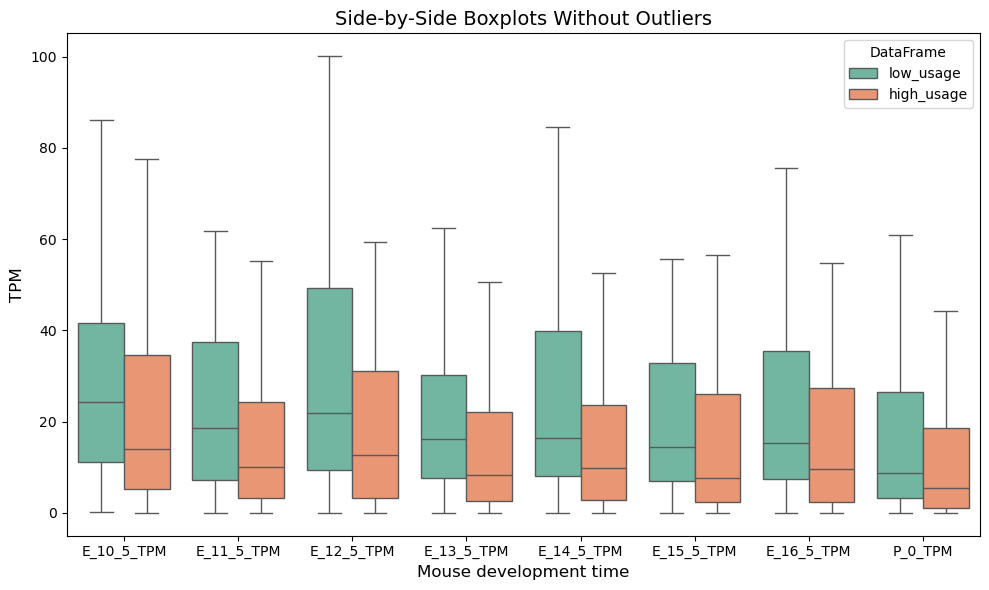

In [289]:
# Combine the two DataFrames for side-by-side plotting
combined_df = pd.concat([
    low_usage.melt(var_name='Column', value_name='Value').assign(Source='low_usage'),
    high_usage.melt(var_name='Column', value_name='Value').assign(Source='high_usage')
])

# Create a boxplot without showing outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='Column', y='Value', hue='Source', data=combined_df, palette='Set2', showfliers=False)

# Customize the plot
plt.title('Side-by-Side Boxplots Without Outliers', fontsize=14)
plt.xlabel('Mouse development time', fontsize=12)
plt.ylabel('TPM', fontsize=12)
plt.legend(title='DataFrame', fontsize=10)
plt.tight_layout()
plt.savefig("/project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/Mouse_RNA_expr_box_plot_211_targets_low_vs_high.pdf")
plt.show()

In [150]:
from scipy.stats import mannwhitneyu

for col in low_usage.columns:
    stat, p_value = mannwhitneyu(low_usage[col], high_usage[col], alternative='two-sided')
    print(f"Mann-Whitney U Test for {col}: Statistic = {stat:.3f}, P-value = {p_value:.3e}")


Mann-Whitney U Test for E_10_5_TPM: Statistic = 5406.000, P-value = 1.392e-02
Mann-Whitney U Test for E_11_5_TPM: Statistic = 5532.500, P-value = 5.276e-03
Mann-Whitney U Test for E_12_5_TPM: Statistic = 5534.000, P-value = 5.212e-03
Mann-Whitney U Test for E_13_5_TPM: Statistic = 5526.000, P-value = 5.559e-03
Mann-Whitney U Test for E_14_5_TPM: Statistic = 5555.000, P-value = 4.391e-03
Mann-Whitney U Test for E_15_5_TPM: Statistic = 5474.500, P-value = 8.335e-03
Mann-Whitney U Test for E_16_5_TPM: Statistic = 5325.500, P-value = 2.451e-02
Mann-Whitney U Test for P_0_TPM: Statistic = 5387.000, P-value = 1.596e-02


In [154]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

p_values = []
stats = []
columns = low_usage.columns

# Perform Mann-Whitney U test for each column
for col in columns:
    stat, p_value = mannwhitneyu(low_usage[col], high_usage[col], alternative='two-sided')
    stats.append(stat)
    p_values.append(p_value)

# Adjust p-values using Benjamini-Hochberg (FDR) correction
adjusted_p_values = multipletests(p_values, method='fdr_bh')[1]

# Print results
for col, stat, p_adj in zip(columns, stats, adjusted_p_values):
    print(f"Mann-Whitney U Test for {col}: Statistic = {stat:.3f}, Adjusted P-value = {p_adj:.3e}")


Mann-Whitney U Test for E_10_5_TPM: Statistic = 5513.000, Adjusted P-value = 1.384e-02
Mann-Whitney U Test for E_11_5_TPM: Statistic = 5643.500, Adjusted P-value = 8.389e-03
Mann-Whitney U Test for E_12_5_TPM: Statistic = 5643.000, Adjusted P-value = 8.389e-03
Mann-Whitney U Test for E_13_5_TPM: Statistic = 5633.000, Adjusted P-value = 8.389e-03
Mann-Whitney U Test for E_14_5_TPM: Statistic = 5667.000, Adjusted P-value = 8.389e-03
Mann-Whitney U Test for E_15_5_TPM: Statistic = 5583.500, Adjusted P-value = 9.979e-03
Mann-Whitney U Test for E_16_5_TPM: Statistic = 5430.500, Adjusted P-value = 1.933e-02
Mann-Whitney U Test for P_0_TPM: Statistic = 5496.000, Adjusted P-value = 1.384e-02


In [151]:
average_row = low_usage.mean()
low_usage.loc['low_usage_average'] = average_row
low_usage_avg = low_usage.loc["low_usage_average",:]
low_usage_avg = pd.DataFrame(low_usage_avg)

In [179]:
high_usage = reordered_df.loc["Sirt6":].iloc[1:]
average_row = high_usage.mean()
high_usage.loc['high_usage_average'] = average_row

high_usage_avg = high_usage.loc["high_usage_average",:]
high_usage_avg = pd.DataFrame(high_usage_avg)

In [182]:
combined_usage = pd.concat([low_usage_avg,high_usage_avg], axis=1)

In [183]:
combined_usage["Fold_change"] = combined_usage["low_usage_average"]/combined_usage["high_usage_average"]

In [184]:
combined_usage["Fold_change"] = combined_usage["Fold_change"] .round(2)

In [187]:
#combined_usage.to_csv("mouse_polyA_expr_encode_low_high_usage.csv")

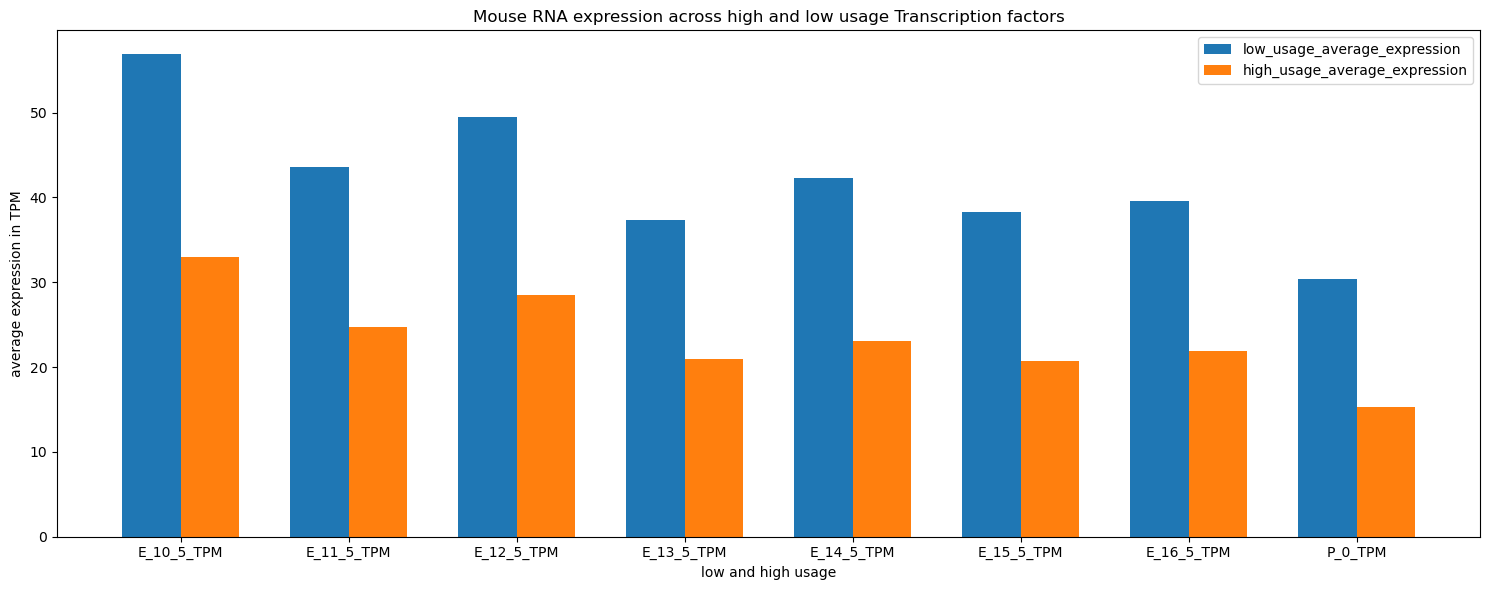

In [188]:
import matplotlib.pyplot as plt
import numpy as np

# Set the figure size
plt.figure(figsize=(15, 6))

# Set the x locations for the bars
x = np.arange(len(combined_usage.index))  # the label locations

# Set the width of the bars
width = 0.35  # the width of the bars

# Plotting the bars
bars1 = plt.bar(x - width/2, combined_usage['low_usage_average'], width, label='low_usage_average_expression')
bars2 = plt.bar(x + width/2, combined_usage['high_usage_average'], width, label='high_usage_average_expression')

# Adding labels and title
plt.xlabel('low and high usage')
plt.ylabel('average expression in TPM')
plt.title('Mouse RNA expression across high and low usage Transcription factors')
plt.xticks(x, combined_usage.index)  # Set x-ticks to the index of the DataFrame
plt.legend()
#plt.savefig('Average_RNA_expr_mouse_high_low_usage_encode.pdf', format='pdf')


plt.tight_layout()
plt.show()
